In [2]:
import numpy as np
import pandas as pd
from torchvision.datasets import CIFAR10
cifar10_train = CIFAR10(root='./data', train=True, download=True)

In [3]:

image, label = cifar10_train[0]
print(type(image))
print(image.size if hasattr(image, 'size') else image.shape)
print (label)

<class 'PIL.Image.Image'>
(32, 32)
6


In [4]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(60),
    transforms.ToTensor()
])

view1 = transform(image)
view2 = transform(image)
view3 = transform(image)

print(f"View1 shape: {view1.shape}")
print(f"View2 shape: {view2.shape}")
print(f"{torch.equal(view1, view2)}")

View1 shape: torch.Size([3, 32, 32])
View2 shape: torch.Size([3, 32, 32])
False


In [5]:
from torch.utils.data import Dataset
class MultiViewDataset(Dataset):
    def __init__(self, orig_data, transform, num_views= 4):
        self.orig_data = orig_data
        self.transform = transform
        self.num_views = num_views
    
    def __len__(self):
        return len(self.orig_data)

    def __getitem__(self, dataset):
        image, label = self.orig_data[dataset]

        views = []
        for i in range(self.num_views):
            view = self.transform(image)
            views.append(view)
        views = torch.stack(views)
        return views, label

multi_view_cifar10_train = MultiViewDataset(cifar10_train, transform, num_views=4)


In [6]:
print(dir(multi_view_cifar10_train))
views, label = multi_view_cifar10_train[0]
print(f"Views shape: {views.shape}")
print(f"Label: {label}")

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'num_views', 'orig_data', 'transform']
Views shape: torch.Size([4, 3, 32, 32])
Label: 6


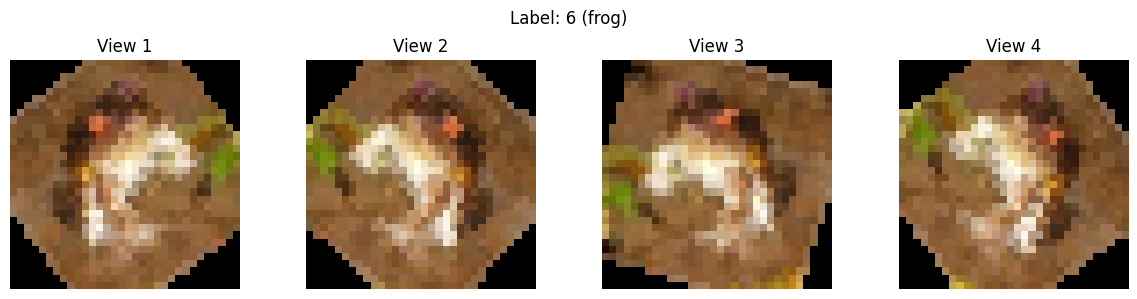

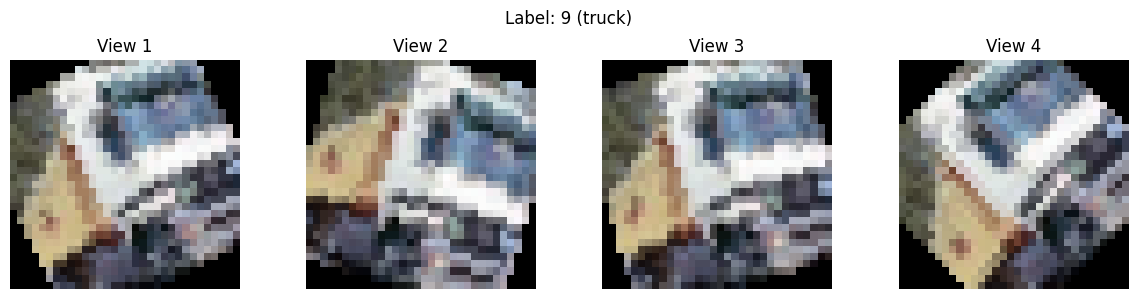

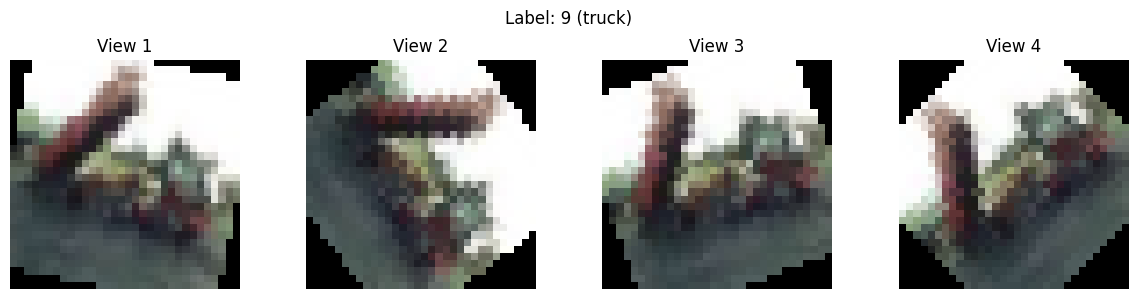

In [7]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
def show_views(dataset, idx=0):
    """Visualize the multiple views of a single image"""
    views, label = dataset[idx]
    
    # views shape: (num_views, 3, 32, 32)
    num_views = views.shape[0]
    
    fig, axes = plt.subplots(1, num_views, figsize=(12, 3))
    
    for i in range(num_views):
        # Convert from (3, 32, 32) to (32, 32, 3) for display
        img = views[i].permute(1, 2, 0).numpy()
        
        # If you normalized, you might need to denormalize
        # For now, clip to [0, 1] range
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f'View {i+1}')
        axes[i].axis('off')
    
    plt.suptitle(f'Label: {label} ({classes[label]})')
    plt.tight_layout()
    plt.show()

# Test it
show_views(multi_view_cifar10_train, idx=0)
show_views(multi_view_cifar10_train, idx=1)
show_views(multi_view_cifar10_train, idx=2)

In [8]:
class model_backbone(nn.Module):
     def __init__(self, embedding_dim=84):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 4)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, embedding_dim)
         
     def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

In [9]:
backbone = model_backbone(embedding_dim=84)
views, label = multi_view_cifar10_train[0]
views[0]
view = views[0].unsqueeze(0)
output = backbone(view)
print(f"Output shape: {output.shape}")
print(output)

Output shape: torch.Size([1, 84])
tensor([[0.0000, 0.0000, 0.0736, 0.0719, 0.0000, 0.0000, 0.0000, 0.0057, 0.0312,
         0.0789, 0.1084, 0.0000, 0.0456, 0.0000, 0.0000, 0.0754, 0.0000, 0.0000,
         0.0000, 0.0437, 0.0000, 0.0000, 0.0000, 0.0059, 0.0121, 0.0948, 0.0051,
         0.0255, 0.0000, 0.0000, 0.0000, 0.0389, 0.0507, 0.0000, 0.0679, 0.0000,
         0.0099, 0.0000, 0.0000, 0.0252, 0.0000, 0.0000, 0.0000, 0.0000, 0.0585,
         0.0537, 0.0000, 0.0662, 0.0000, 0.0000, 0.0000, 0.0000, 0.0054, 0.0341,
         0.0443, 0.0120, 0.0311, 0.0497, 0.0157, 0.0762, 0.0679, 0.0439, 0.0321,
         0.1038, 0.0717, 0.0000, 0.0000, 0.0467, 0.0568, 0.0573, 0.0000, 0.0033,
         0.0594, 0.0066, 0.0493, 0.0000, 0.0000, 0.1161, 0.0252, 0.0000, 0.0695,
         0.0000, 0.0000, 0.0510]], grad_fn=<ReluBackward0>)


In [10]:
class MultiViewModel(nn.Module):
    def __init__(self, backbone, embedding_dim=84):
        super().__init__()
        self.backbone = backbone
        self.embedding_dim = embedding_dim

    def forward(self, views):
        batch_size, num_views, c, h, w = views.shape
        views_flat = views.view(batch_size*num_views, c, h, w)
        embeddings_flat = self.backbone(views_flat)
        embeddings = embeddings_flat.view(batch_size, num_views, self.embedding_dim)
        return embeddings


In [11]:
multi_view_model = MultiViewModel(backbone, embedding_dim=84)
views, label = multi_view_cifar10_train[0]
views = views.unsqueeze(0)
print(f"INput shape: {views.shape} ")
embeddings = multi_view_model(views)
print(f"Output shape: {embeddings.shape}")

INput shape: torch.Size([1, 4, 3, 32, 32]) 
Output shape: torch.Size([1, 4, 84])


In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(multi_view_cifar10_train, batch_size=8, shuffle=True)
views_batch, labels_batch = next(iter(train_loader))
print(f"Batch views shape: {views_batch.shape}")
print(f"Batch labels shape: {labels_batch.shape}")

embeddings_batch = multi_view_model(views_batch)
print(f"Batch embeddings shape: {embeddings_batch.shape}")

Batch views shape: torch.Size([8, 4, 3, 32, 32])
Batch labels shape: torch.Size([8])
Batch embeddings shape: torch.Size([8, 4, 84])


In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)
        return x


In [14]:
transformer_block = TransformerBlock(
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    dropout=0.1)




In [15]:
class CompleteMultiViewModel(nn.Module):
    def __init__(self, backbone, embed_dim=84, num_heads=4, ff_dim=256, num_classes=10, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        self.transformer = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.embed_dim = embed_dim
    
    def forward(self, views):
        batch_size, num_views, c, h, w = views.shape
        views_flat = views.view(batch_size * num_views, c, h, w)
        embeddings_flat = self.backbone(views_flat)  # (batch*num_views, 84)
        embeddings = embeddings_flat.view(batch_size, num_views, self.embed_dim)
        embeddings = self.transformer(embeddings)
        aggregated = embeddings.mean(dim=1)  # ✅ This is the key aggregation step!
        logits = self.classifier(aggregated)
        return logits

backbone = model_backbone(embedding_dim=84)
final_model = CompleteMultiViewModel(
    backbone=backbone,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1)

views_batch, labels_batch = next(iter(train_loader))
print(f"Input views shape: {views_batch.shape}")  # (batch, 4, 3, 32, 32)
print(f"Labels shape: {labels_batch.shape}")      # (batch,)

# Forward pass
logits = final_model(views_batch)
print(f"Output logits shape: {logits.shape}")     # (batch, 10)

# Get predictions
predictions = logits.argmax(dim=1)
print(f"Predictions shape: {predictions.shape}")  # (batch,)
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels_batch[:5]}")

Input views shape: torch.Size([8, 4, 3, 32, 32])
Labels shape: torch.Size([8])
Output logits shape: torch.Size([8, 10])
Predictions shape: torch.Size([8])
Sample predictions: tensor([6, 1, 6, 6, 1])
Sample labels: tensor([2, 2, 6, 9, 1])


In [16]:
import copy

backbone1 = model_backbone(embedding_dim=84)
model_sgd = CompleteMultiViewModel(
    backbone=backbone1,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1
)

backbone2 = model_backbone(embedding_dim=84)
model_adam = CompleteMultiViewModel(
    backbone=backbone2,
    embed_dim=84,
    num_heads=4,
    ff_dim=256,
    num_classes=10,
    dropout=0.1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_sgd = model_sgd.to(device)
model_adam = model_adam.to(device)

criterion = nn.CrossEntropyLoss()
optimiser_sgd = torch.optim.SGD(model_sgd.parameters(), lr = 0.001, momentum = 0.9)
optimiser_adam = torch.optim.Adam(model_adam.parameters(), lr = 0.001)


In [17]:
def train_model(model, train_loader, criterion, optimizer, epochs, device, model_name="Model"):
    model.train()  # Set to training mode
    train_losses = []  # Track loss over epochs
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, data in enumerate(train_loader):
            views, labels = data
            views, labels = views.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(views)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            if i % 500 == 499:
                print(f'[{model_name}] Epoch {epoch+1}, Batch {i+1}: '
                      f'Loss: {running_loss/500:.3f}, '
                      f'Acc: {100*correct/total:.2f}%')
                running_loss = 0.0
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        print(f'[{model_name}] Epoch {epoch+1}/{epochs} Complete - '
              f'Avg Loss: {epoch_loss:.3f}, Accuracy: {epoch_acc:.2f}%')
    
    print(f'[{model_name}] Training Complete!')
    return train_losses

In [18]:
batch_size = 32

train_loader = DataLoader(
    multi_view_cifar10_train, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0 
)

print(f"Training batches: {len(train_loader)}")
print(f"Total training samples: {len(multi_view_cifar10_train)}")

Training batches: 1563
Total training samples: 50000


In [19]:
num_epochs = 15

print("=" * 60)
print("TRAINING WITH SGD")
print("=" * 60)
losses_sgd = train_model(
    model_sgd, 
    train_loader, 
    criterion, 
    optimiser_sgd, 
    num_epochs, 
    device, 
    "SGD"
)

print("\n" + "=" * 60)
print("TRAINING WITH ADAM")
print("=" * 60)
losses_adam = train_model(
    model_adam, 
    train_loader, 
    criterion, 
    optimiser_adam, 
    num_epochs, 
    device, 
    "Adam"
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)

TRAINING WITH SGD
[SGD] Epoch 1, Batch 500: Loss: 2.037, Acc: 24.23%
[SGD] Epoch 1, Batch 1000: Loss: 1.793, Acc: 29.44%
[SGD] Epoch 1, Batch 1500: Loss: 1.699, Acc: 32.48%
[SGD] Epoch 1/15 Complete - Avg Loss: 0.067, Accuracy: 32.75%
[SGD] Epoch 2, Batch 500: Loss: 1.638, Acc: 40.79%
[SGD] Epoch 2, Batch 1000: Loss: 1.606, Acc: 41.50%
[SGD] Epoch 2, Batch 1500: Loss: 1.586, Acc: 41.82%
[SGD] Epoch 2/15 Complete - Avg Loss: 0.062, Accuracy: 41.91%
[SGD] Epoch 3, Batch 500: Loss: 1.530, Acc: 45.07%
[SGD] Epoch 3, Batch 1000: Loss: 1.497, Acc: 45.82%
[SGD] Epoch 3, Batch 1500: Loss: 1.498, Acc: 45.94%
[SGD] Epoch 3/15 Complete - Avg Loss: 0.060, Accuracy: 45.99%
[SGD] Epoch 4, Batch 500: Loss: 1.459, Acc: 47.30%
[SGD] Epoch 4, Batch 1000: Loss: 1.435, Acc: 47.86%
[SGD] Epoch 4, Batch 1500: Loss: 1.405, Acc: 48.42%
[SGD] Epoch 4/15 Complete - Avg Loss: 0.057, Accuracy: 48.40%
[SGD] Epoch 5, Batch 500: Loss: 1.395, Acc: 49.64%
[SGD] Epoch 5, Batch 1000: Loss: 1.383, Acc: 49.97%
[SGD] Epoch

In [26]:
base_transform_test = transforms.Compose([
    transforms.ToTensor()
])

cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=None)
multi_view_test = MultiViewDataset(cifar10_test, transform, num_views=4)
test_loader = DataLoader(multi_view_test, batch_size=32, shuffle=False)
print(f"Test dataset size: {len(multi_view_test)}")
print(f"Test batches: {len(test_loader)}")

Test dataset size: 10000
Test batches: 313


In [27]:
def evaluate_model(model, test_loader, device, model_name="Model"):
    model.eval()  # Set to evaluation mode
    correct = 0
    total = 0
    class_correct = [0] * 10
    class_total = [0] * 10
    
    with torch.no_grad():
        for data in test_loader:
            views, labels = data
            views, labels = views.to(device), labels.to(device)
            outputs = model(views)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    
    overall_accuracy = 100 * correct / total
    class_accuracies = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 
                       for i in range(10)]
    print(f"{model_name} - Test Set Evaluation")
    print(f"Overall Accuracy: {overall_accuracy:.2f}%")
    print(f"\nPer-Class Accuracy:")
    for i, class_name in enumerate(classes):
        print(f"  {class_name:10s}: {class_accuracies[i]:5.2f}%")
    return overall_accuracy, class_accuracies

In [28]:
acc_sgd, class_acc_sgd = evaluate_model(model_sgd, test_loader, device, "SGD Model")
acc_adam, class_acc_adam = evaluate_model(model_adam, test_loader, device, "Adam Model")
print(f"SGD Test Accuracy:  {acc_sgd:.2f}%")
print(f"Adam Test Accuracy: {acc_adam:.2f}%")

SGD Model - Test Set Evaluation
Overall Accuracy: 59.77%

Per-Class Accuracy:
  plane     : 72.50%
  car       : 69.30%
  bird      : 49.30%
  cat       : 41.20%
  deer      : 45.40%
  dog       : 38.90%
  frog      : 81.10%
  horse     : 62.80%
  ship      : 67.00%
  truck     : 70.20%
Adam Model - Test Set Evaluation
Overall Accuracy: 64.22%

Per-Class Accuracy:
  plane     : 71.20%
  car       : 73.50%
  bird      : 50.10%
  cat       : 55.40%
  deer      : 68.90%
  dog       : 43.20%
  frog      : 67.60%
  horse     : 71.40%
  ship      : 70.00%
  truck     : 70.90%
SGD Test Accuracy:  59.77%
Adam Test Accuracy: 64.22%


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, test_loader, device, model_name="Model"):
    model.eval()
    
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for data in test_loader:
            views, labels = data
            views, labels = views.to(device), labels.to(device)
            
            outputs = model(views)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Percentage (%)'})
    
    plt.title(f'{model_name} - Confusion Matrix (Normalized)', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(f"{model_name} - Top Confusions")
    confusions = []
    for i in range(10):
        for j in range(10):
            if i != j and cm[i, j] > 0:
                confusions.append((classes[i], classes[j], cm[i, j], cm_normalized[i, j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    print(f"{'True Class':<10} {'Predicted As':<10} {'Count':<8} {'%':<8}")
    for true_class, pred_class, count, percent in confusions[:10]:  # Top 10
        print(f"{true_class:<10} {pred_class:<10} {count:<8.0f} {percent:<8.1f}%")
    
    return cm, cm_normalized

Confusion matrix for SGD


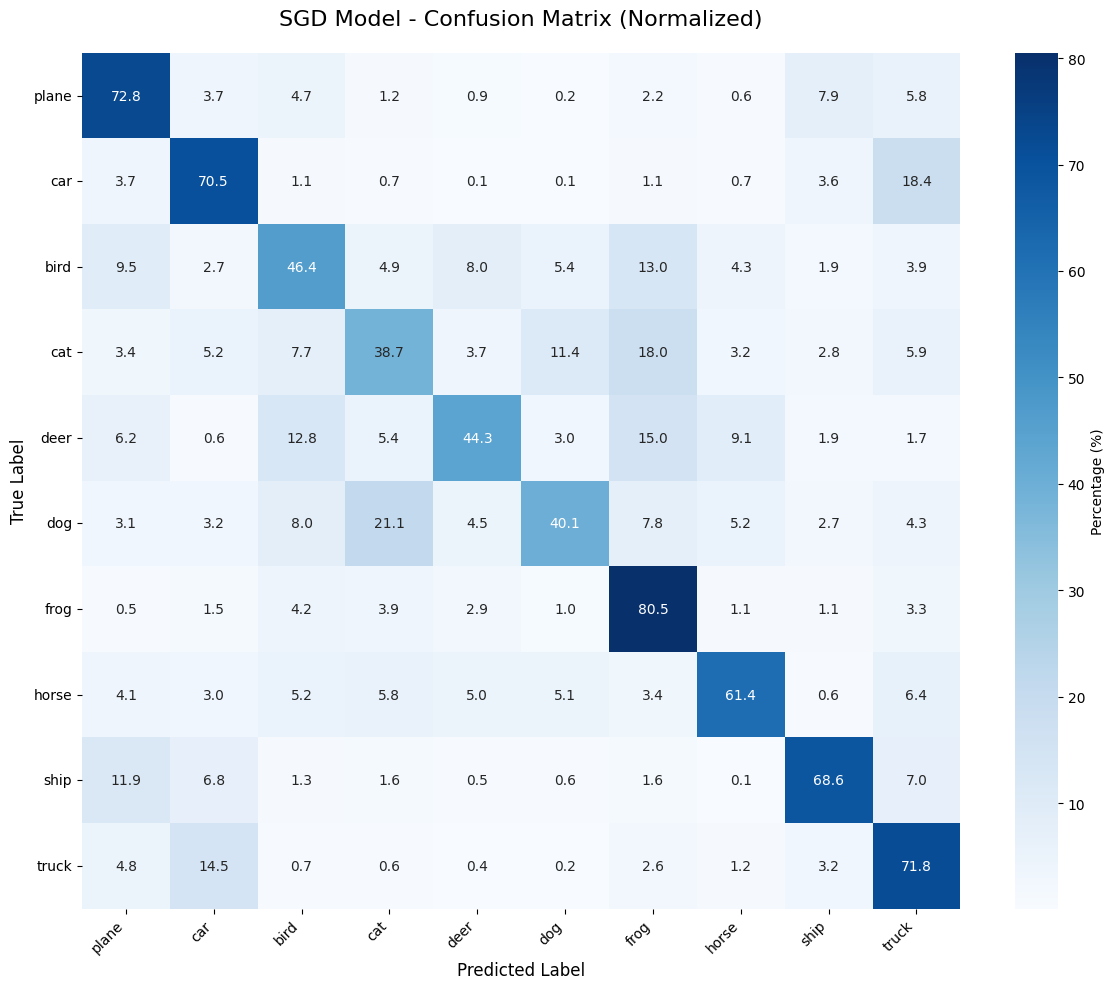

SGD Model - Top Confusions
True Class Predicted As Count    %       
dog        cat        211      21.1    %
car        truck      184      18.4    %
cat        frog       180      18.0    %
deer       frog       150      15.0    %
truck      car        145      14.5    %
bird       frog       130      13.0    %
deer       bird       128      12.8    %
ship       plane      119      11.9    %
cat        dog        114      11.4    %
bird       plane      95       9.5     %


Confusion matrix for Adam


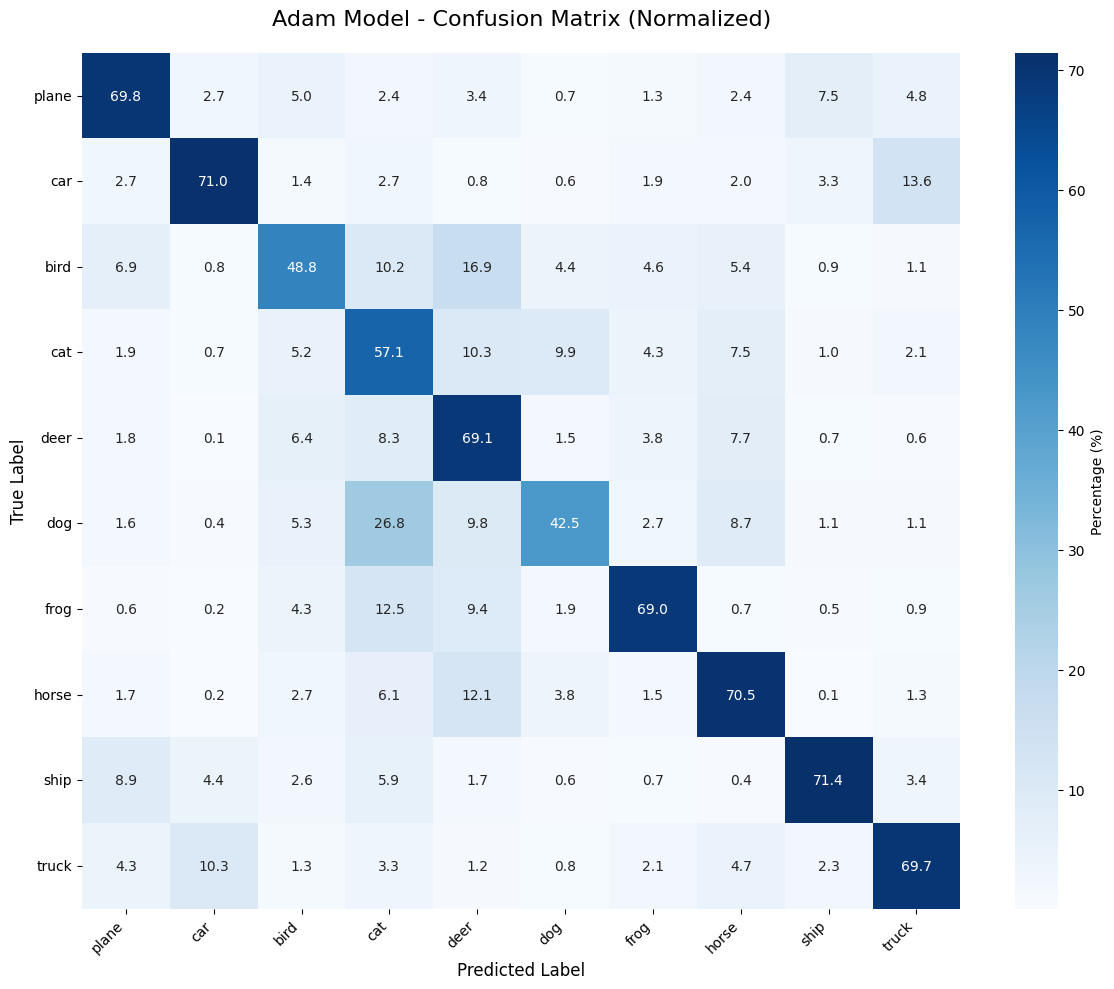

Adam Model - Top Confusions
True Class Predicted As Count    %       
dog        cat        268      26.8    %
bird       deer       169      16.9    %
car        truck      136      13.6    %
frog       cat        125      12.5    %
horse      deer       121      12.1    %
cat        deer       103      10.3    %
truck      car        103      10.3    %
bird       cat        102      10.2    %
cat        dog        99       9.9     %
dog        deer       98       9.8     %


In [30]:
print("Confusion matrix for SGD")
cm_sgd, cm_norm_sgd = plot_confusion_matrix(model_sgd, test_loader, device, "SGD Model")

print("\n")

print("Confusion matrix for Adam")
cm_adam, cm_norm_adam = plot_confusion_matrix(model_adam, test_loader, device, "Adam Model")